In [4]:
# importing essential libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Data Exploration & Cleaning

In [5]:
df = pd.read_excel(r'Data\premiums.xlsx')
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Genetical_Risk,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,0,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,0,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,0,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,0,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,0,15610


In [6]:
#cleaning the column names

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,genetical_risk,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,0,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,0,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,0,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,0,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,0,15610


In [7]:
# handdling missing values

df.isna().sum()

age                       0
gender                    0
region                    0
marital_status            0
number_of_dependants      0
bmi_category              0
smoking_status           11
employment_status         2
income_level             13
income_lakhs              0
medical_history           0
insurance_plan            0
genetical_risk            0
annual_premium_amount     0
dtype: int64

In [8]:
# dropping the income_level column as income lakhs is already avaialbe

df.drop(columns=['income_level'], inplace=True)

In [9]:
# dropping the missing value rows as not very much data is missing

df.dropna(inplace=True)
df.shape

(49987, 13)

In [10]:
# checking for duplicates

df.duplicated().sum()

np.int64(0)

In [11]:
# checking for stats

df.describe()

,age,number_of_dependants,income_lakhs,genetical_risk,annual_premium_amount
count,49987.000000,49987.000000,49987.000000,49987.000000,49987.000000
mean,34.591514,1.711885,23.017365,1.006442,15766.707584
std,14.999780,1.498212,24.220489,1.637861,8419.381321
min,18.000000,-3.000000,1.000000,0.000000,3501.000000
25%,22.000000,0.000000,7.000000,0.000000,8608.000000
50%,31.000000,2.000000,17.000000,0.000000,13928.000000
75%,45.000000,3.000000,31.000000,2.000000,22272.000000
max,356.000000,5.000000,930.000000,5.000000,43471.000000


In [12]:
# Removing outliers for age

df[df['age'] > 100].shape

df = df[df['age'] <= 100]
df.shape

(49929, 13)

In [13]:
# removing the negative values from number of dependants column

df['number_of_dependants'] = df['number_of_dependants'].abs()

In [14]:
df['number_of_dependants'].unique()

array([0, 2, 3, 4, 1, 5])

<Axes: xlabel='income_lakhs', ylabel='Count'>

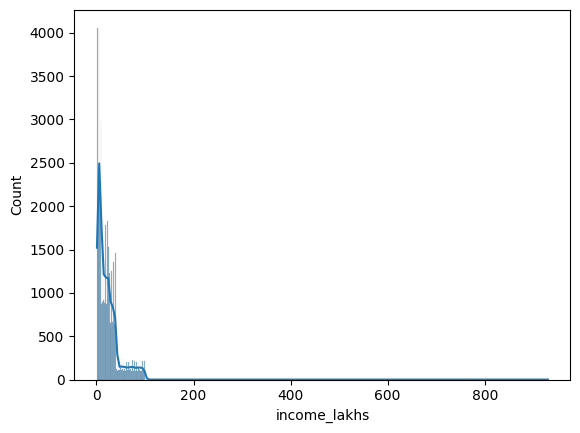

In [15]:
# checking the outliers in income lakhs column

sns.histplot(df['income_lakhs'], kde=True)

<Axes: xlabel='income_lakhs', ylabel='Count'>

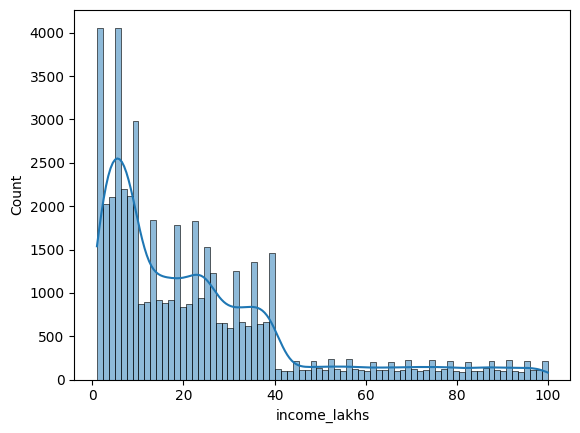

In [16]:
#removing the outliers from income lakhs column

df = df[df['income_lakhs'] <= 100] 
df.shape
sns.histplot(df['income_lakhs'], kde=True)

<Axes: xlabel='annual_premium_amount', ylabel='Count'>

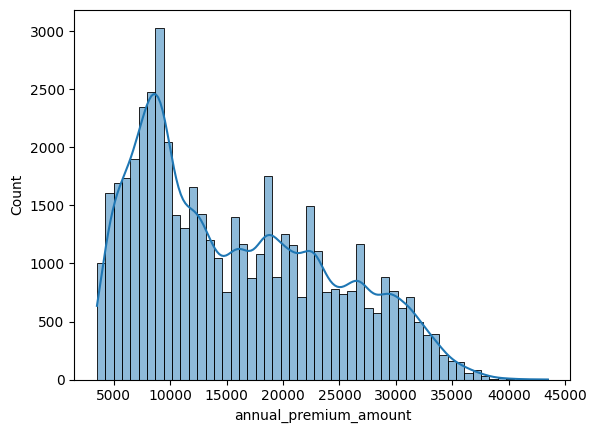

In [17]:
sns.histplot(df['annual_premium_amount'], kde=True)

In [18]:
#checking unique items of all the categorical columns

for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

gender: ['Male' 'Female']
region: ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status: ['Unmarried' 'Married']
bmi_category: ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status: ['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
employment_status: ['Salaried' 'Self-Employed' 'Freelancer']
medical_history: ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan: ['Bronze' 'Silver' 'Gold']


In [19]:
# mapping the region column as per indian regions

region_map = {
    'Northwest': 'North',
    'Northeast': 'East',
    'Southwest': 'West',
    'Southeast': 'South'
}

df['region'] = df['region'].map(region_map)

In [20]:
df['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional', 'Does Not Smoke',
       'Not Smoking', 'Smoking=0'], dtype=object)

In [21]:
# correcting the smoking column values

smoking_map = {
    'No Smoking':'No Smoking', 
    'Regular': 'Regular', 
    'Occasional': 'Occasional', 
    'Does Not Smoke': 'No Smoking',
    'Not Smoking': 'No Smoking',
    'Smoking=0': 'No Smoking',
    }

df['smoking_status'] = df['smoking_status'].map(smoking_map)
df['smoking_status'].unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

In [22]:
df['medical_history'].unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [23]:
# Creating medical_risk_score column based on medical history

disease_weights = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure": 6,
    "thyroid": 5,
    "no disease": 0,
    "none": 0
}

def calculate_risk_score(medical_history):
    diseases = medical_history.split(" & ")
    risk_score = sum(disease_weights.get(disease.strip().lower(), 0) for disease in diseases)
    return risk_score

df['medical_risk_score'] = df['medical_history'].apply(calculate_risk_score)
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_lakhs,medical_history,insurance_plan,genetical_risk,annual_premium_amount,medical_risk_score
0,26,Male,North,Unmarried,0,Normal,No Smoking,Salaried,6,Diabetes,Bronze,0,9053,6
1,29,Female,South,Married,2,Obesity,Regular,Salaried,6,Diabetes,Bronze,0,16339,6
2,49,Female,East,Married,2,Normal,No Smoking,Self-Employed,20,High blood pressure,Silver,0,18164,6
3,30,Female,South,Married,3,Normal,No Smoking,Salaried,77,No Disease,Gold,0,20303,0
4,56,Male,East,Married,3,Obesity,Occasional,Self-Employed,14,Diabetes,Bronze,0,15610,6


In [24]:
df.pivot_table(index='medical_history', values='medical_risk_score', aggfunc='mean').sort_values(by='medical_risk_score', ascending=False)

,medical_risk_score
medical_history,
Diabetes & Heart disease,14.0
High blood pressure & Heart disease,14.0
Diabetes & High blood pressure,12.0
Diabetes & Thyroid,11.0
Heart disease,8.0
Diabetes,6.0
High blood pressure,6.0
Thyroid,5.0
No Disease,0.0


In [25]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

gender: ['Male' 'Female']
region: ['North' 'South' 'East' 'West']
marital_status: ['Unmarried' 'Married']
bmi_category: ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status: ['No Smoking' 'Regular' 'Occasional']
employment_status: ['Salaried' 'Self-Employed' 'Freelancer']
medical_history: ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan: ['Bronze' 'Silver' 'Gold']


In [26]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_lakhs,medical_history,insurance_plan,genetical_risk,annual_premium_amount,medical_risk_score
0,26,Male,North,Unmarried,0,Normal,No Smoking,Salaried,6,Diabetes,Bronze,0,9053,6
1,29,Female,South,Married,2,Obesity,Regular,Salaried,6,Diabetes,Bronze,0,16339,6
2,49,Female,East,Married,2,Normal,No Smoking,Self-Employed,20,High blood pressure,Silver,0,18164,6
3,30,Female,South,Married,3,Normal,No Smoking,Salaried,77,No Disease,Gold,0,20303,0
4,56,Male,East,Married,3,Obesity,Occasional,Self-Employed,14,Diabetes,Bronze,0,15610,6


In [27]:
df2 = df.drop(columns=['medical_history']).copy()

### Feature Selection & EDA

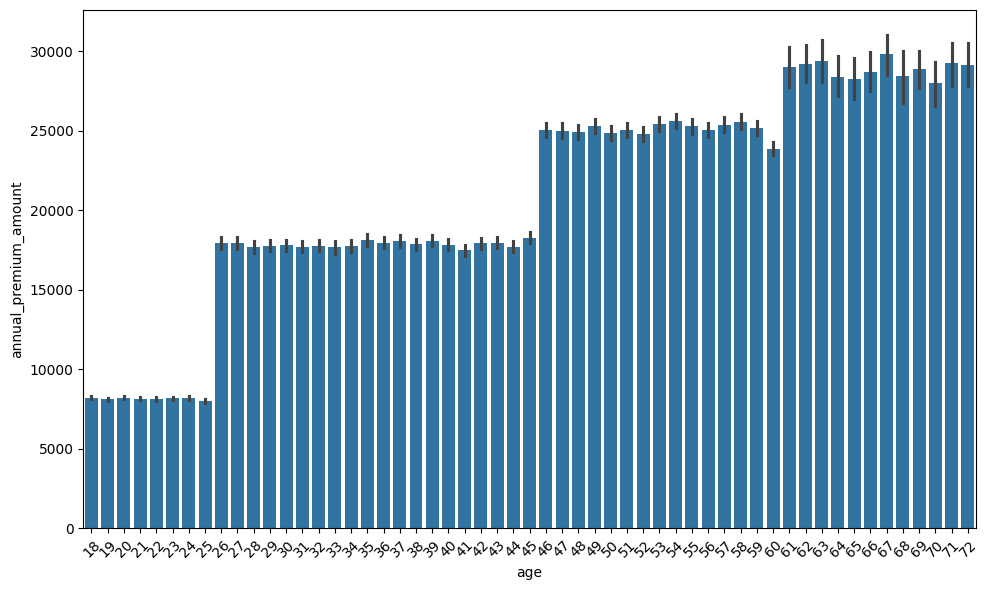

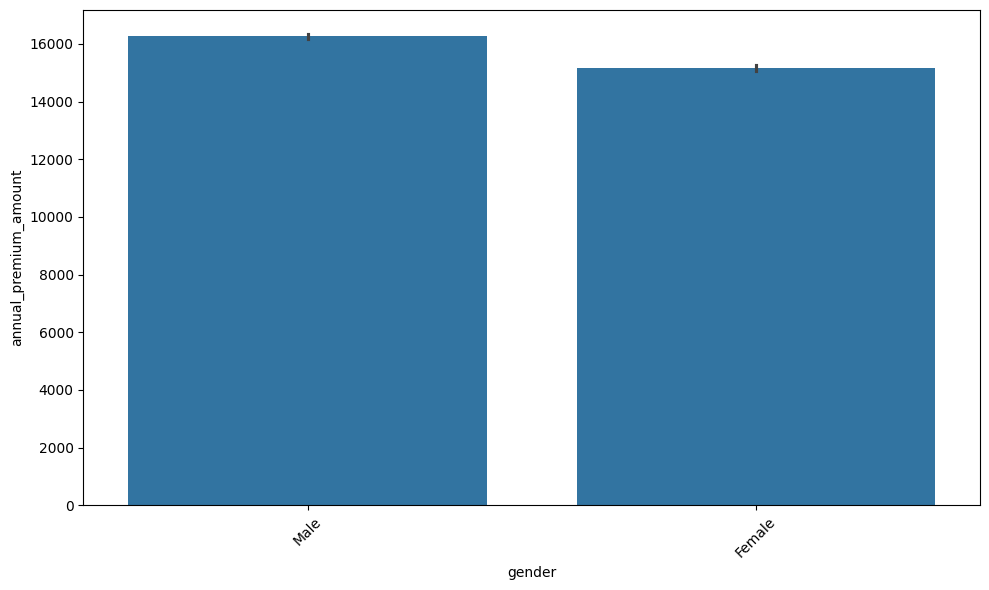

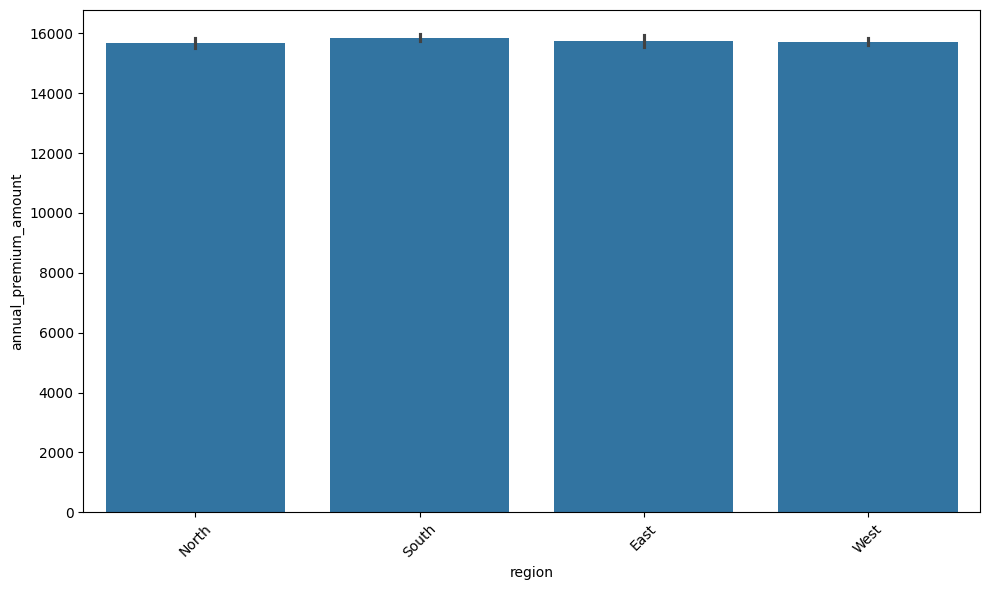

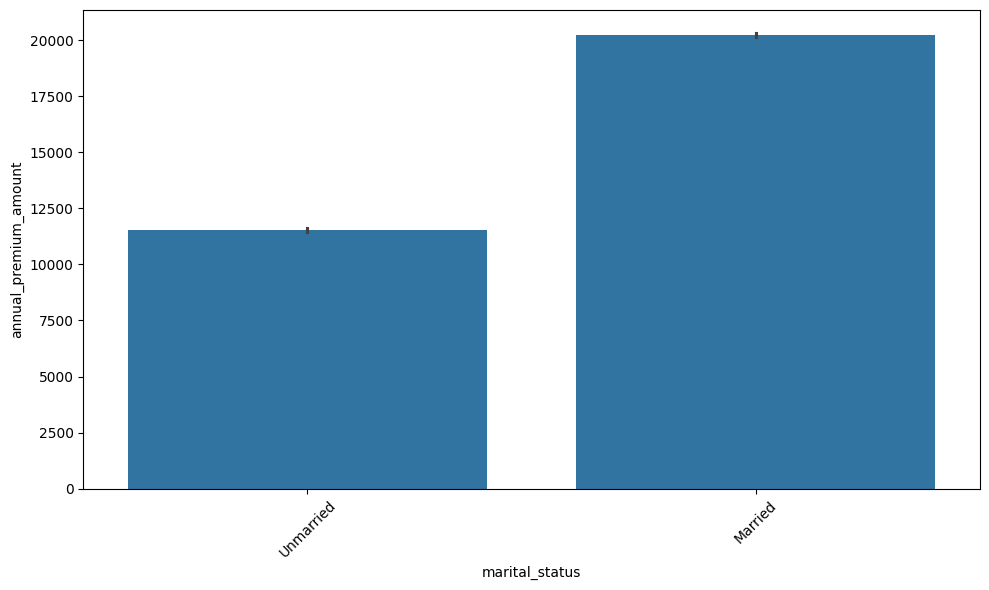

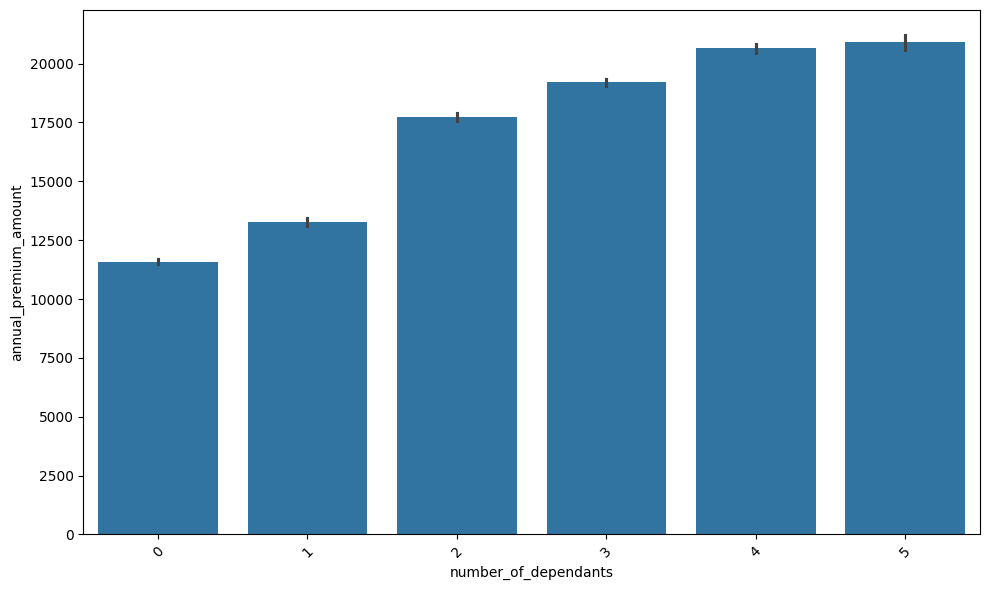

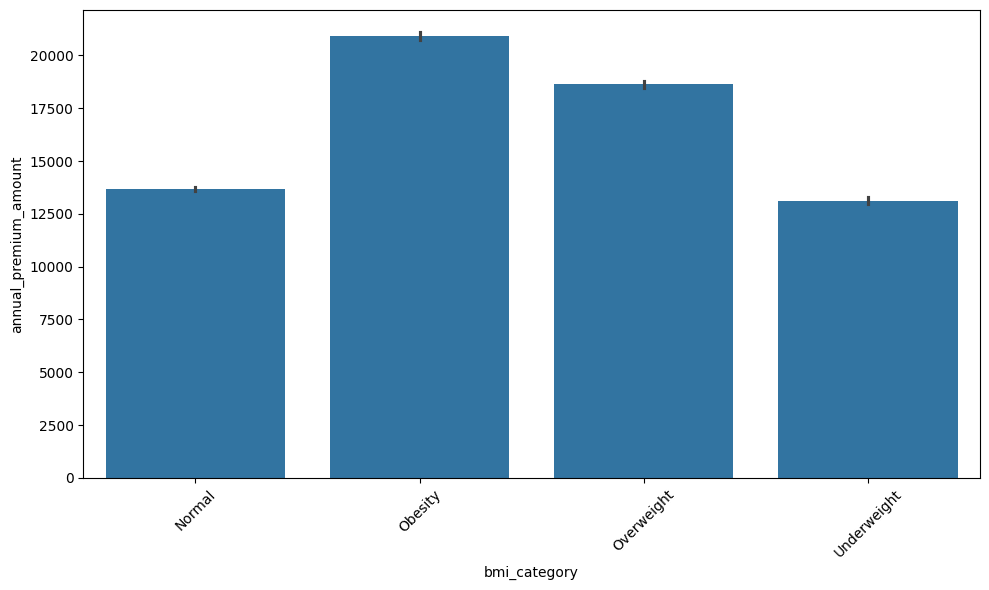

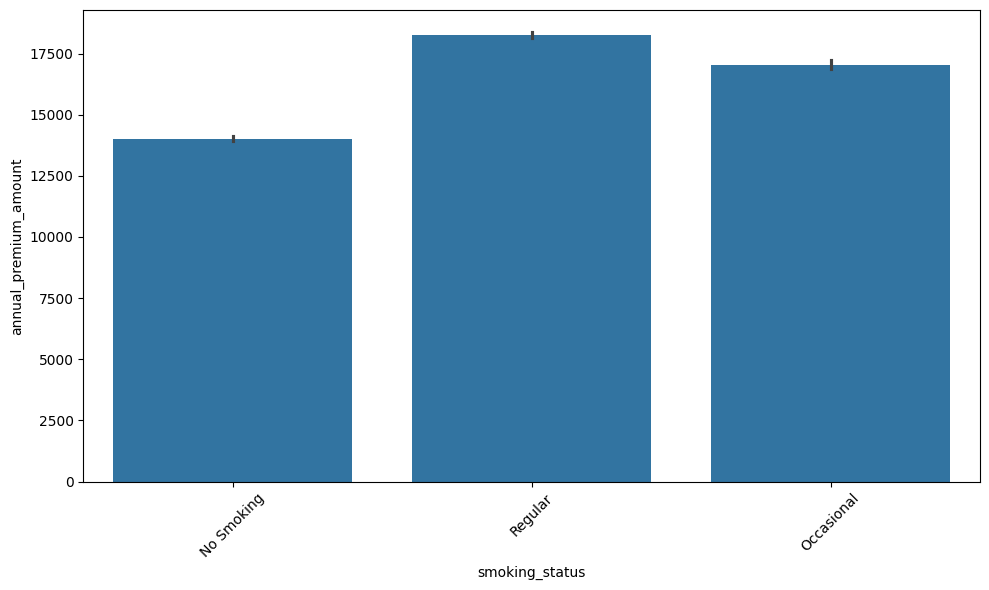

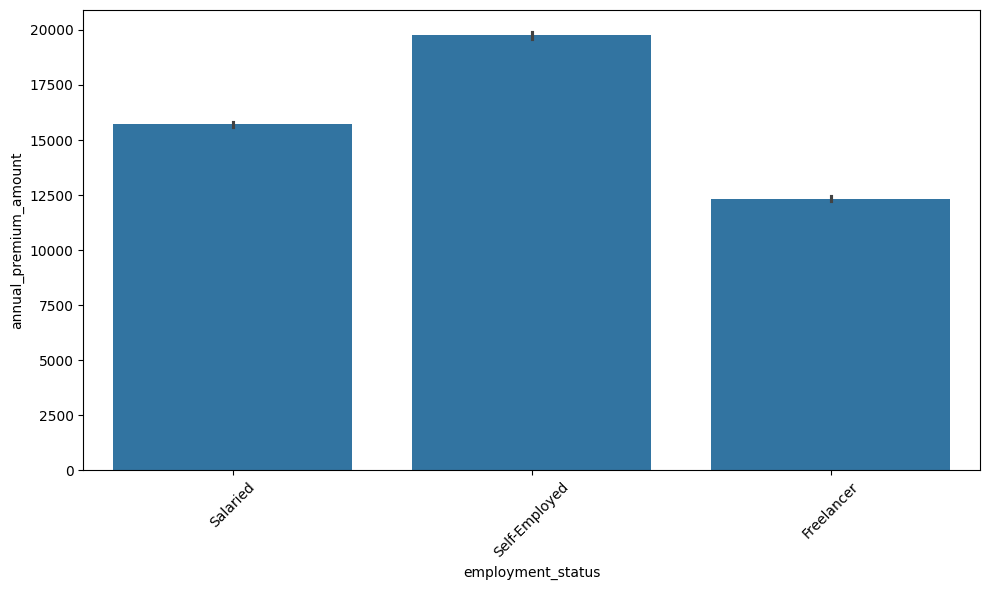

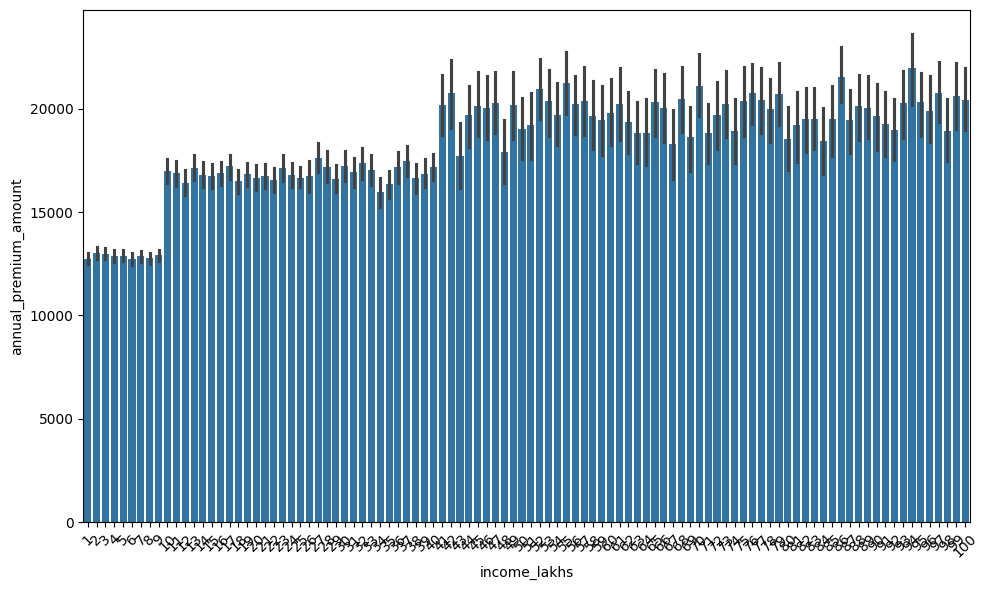

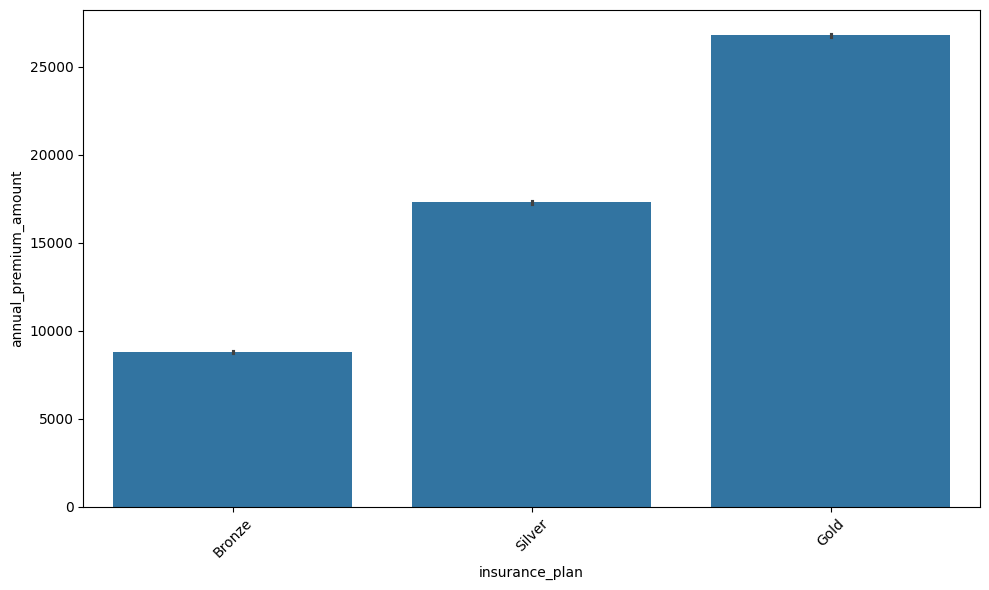

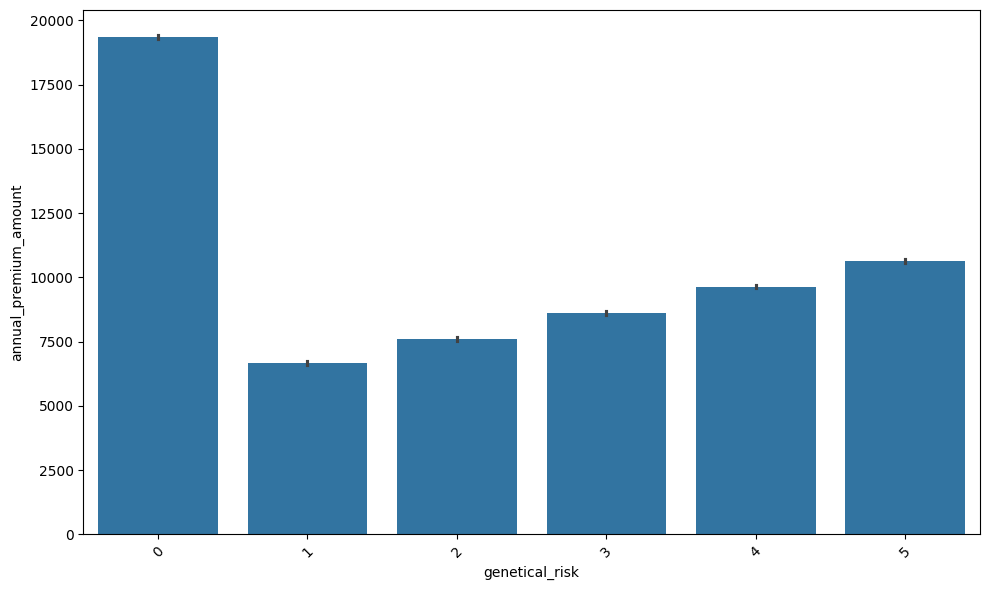

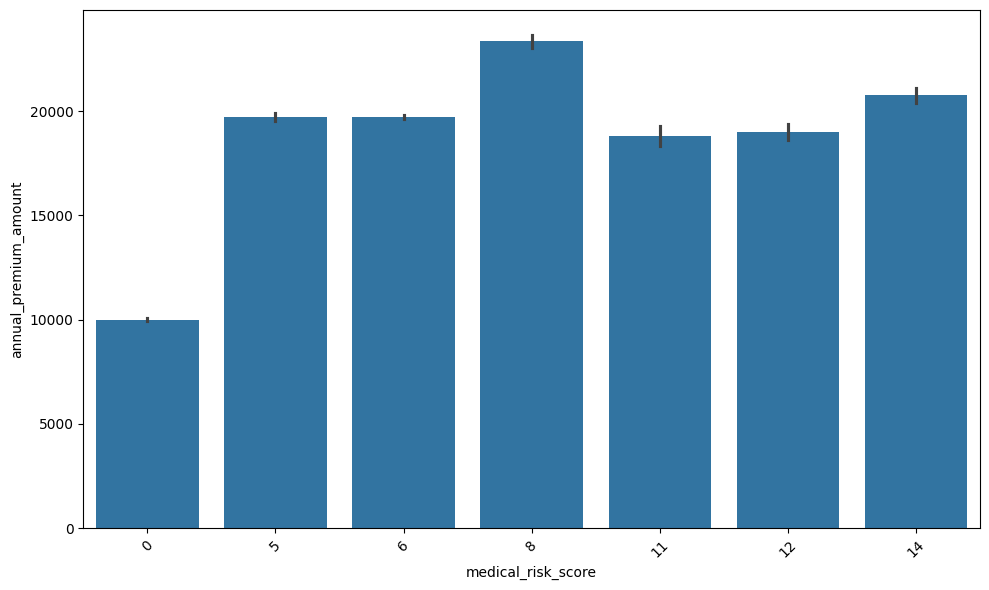

In [37]:
columns = df2.drop(columns=['annual_premium_amount']).columns
for col in columns:
    plt.figure(figsize = (10, 6))
    sns.barplot(x=col, y='annual_premium_amount', data=df2)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [ ]:
# mapped insurance plan column based on annual premium amount
df2['insurance_plan'] = df2['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})
df2.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_lakhs,insurance_plan,genetical_risk,annual_premium_amount,medical_risk_score
0,26,Male,North,Unmarried,0,Normal,No Smoking,Salaried,6,1,0,9053,6
1,29,Female,South,Married,2,Obesity,Regular,Salaried,6,1,0,16339,6
2,49,Female,East,Married,2,Normal,No Smoking,Self-Employed,20,2,0,18164,6
3,30,Female,South,Married,3,Normal,No Smoking,Salaried,77,3,0,20303,0
4,56,Male,East,Married,3,Obesity,Occasional,Self-Employed,14,1,0,15610,6


In [61]:
#encoding the categorical columns using one hot encoding

columns_to_encode = ['gender','region','marital_status','bmi_category','smoking_status','employment_status']
df3 = pd.get_dummies(df2, columns=columns_to_encode, drop_first=True, dtype=int)
df3.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,annual_premium_amount,medical_risk_score,gender_Male,region_North,region_South,region_West,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,6,1,0,9053,6,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,6,1,0,16339,6,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,20,2,0,18164,6,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,77,3,0,20303,0,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,14,1,0,15610,6,1,0,0,0,0,1,0,0,1,0,0,1


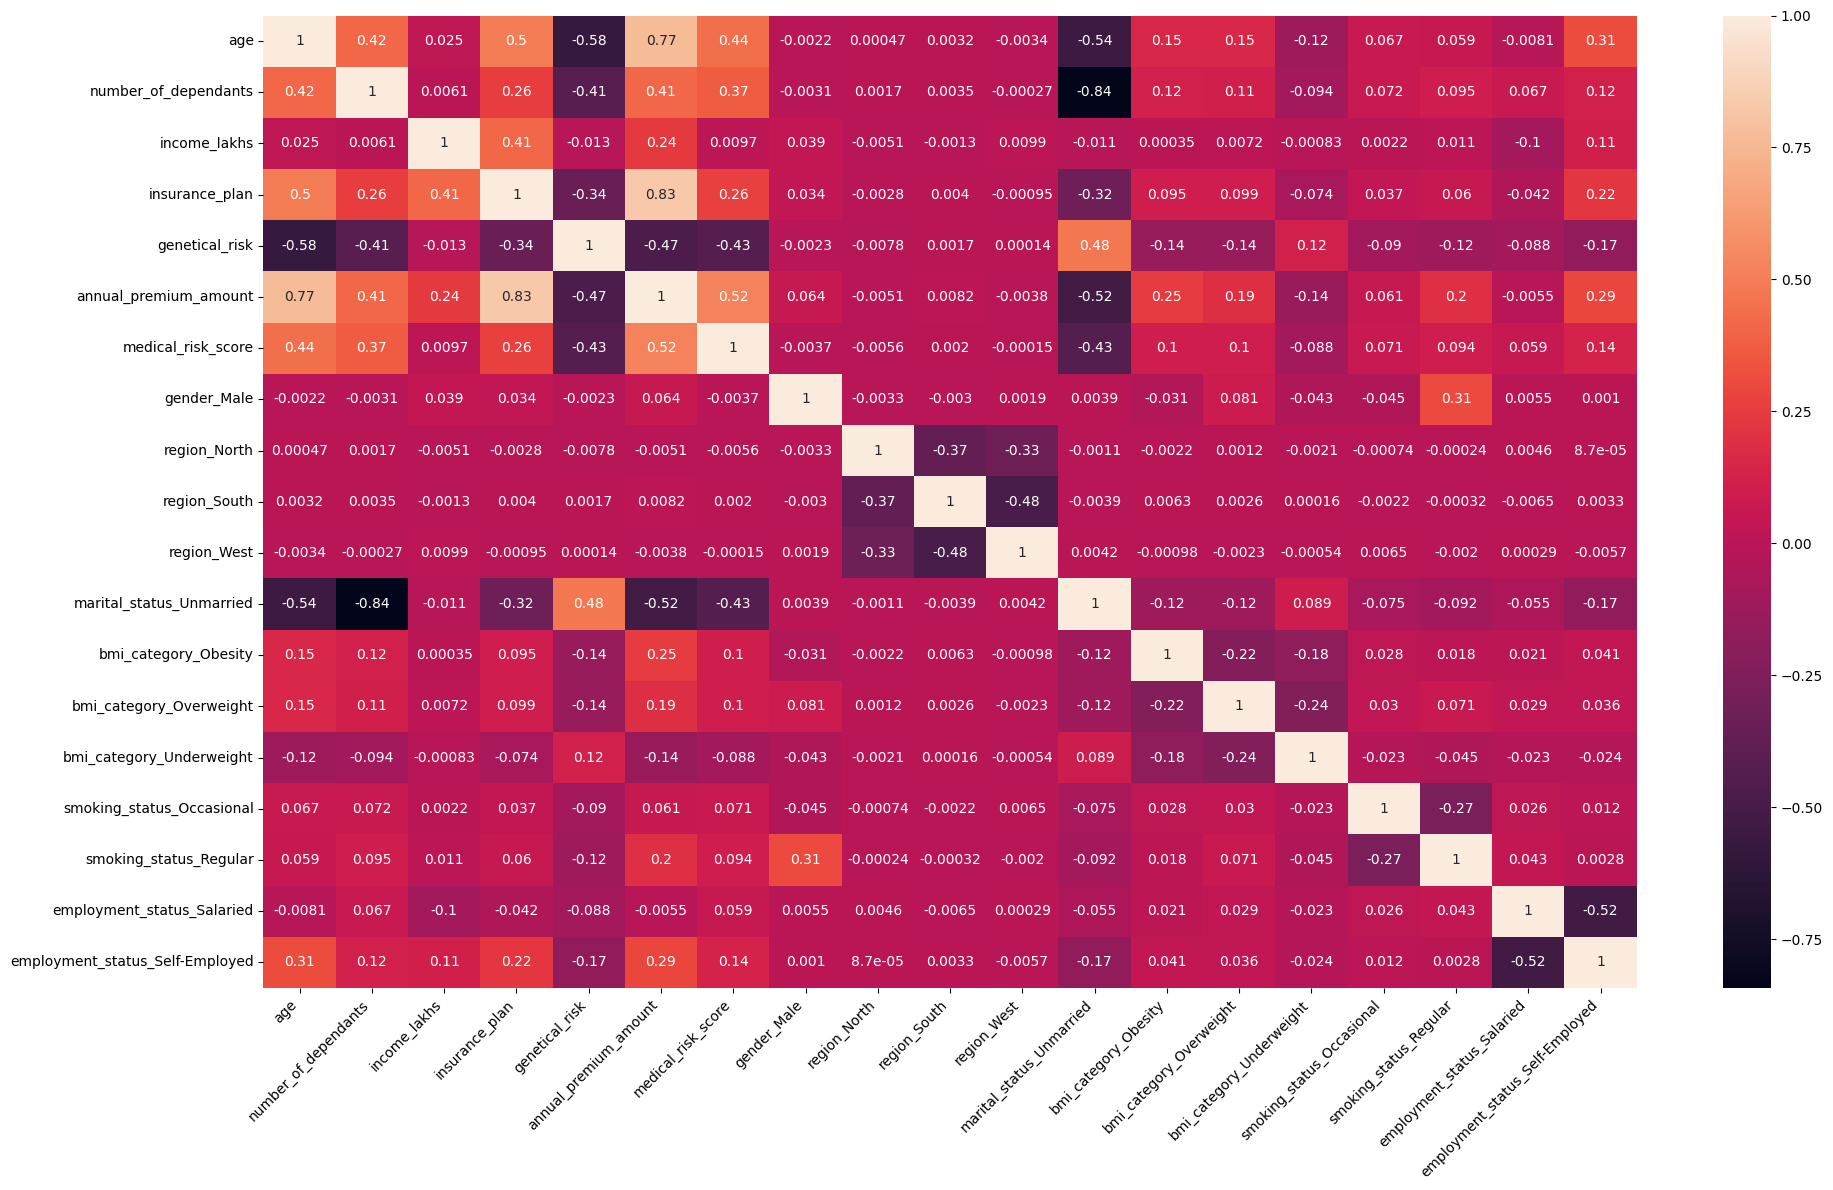

In [62]:
# showing the correlation between the columns
cm = df3.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Model Training & Evaluation of different models

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [63]:
df3.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,annual_premium_amount,medical_risk_score,gender_Male,region_North,region_South,region_West,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,6,1,0,9053,6,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,6,1,0,16339,6,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,20,2,0,18164,6,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,77,3,0,20303,0,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,14,1,0,15610,6,1,0,0,0,0,1,0,0,1,0,0,1


In [64]:
# splitting the data into features and target variable
X = df3.drop(columns=['annual_premium_amount'])
y = df3['annual_premium_amount']

#Sclaed X using MinMaxScaler
columns_to_scale = ['age', 'income_lakhs', 'number_of_dependants', 'medical_risk_score','insurance_plan']
scaler = MinMaxScaler()

X[columns_to_scale] = scaler.fit_transform(X[columns_to_scale])
X.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,medical_risk_score,gender_Male,region_North,region_South,region_West,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.148148,0.0,0.050505,0.0,0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.203704,0.4,0.050505,0.0,0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.574074,0.4,0.191919,0.5,0,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.222222,0.6,0.767677,1.0,0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.703704,0.6,0.131313,0.0,0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


#### Linear Regression

In [66]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# training the model using linear regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
model_lr_pred = model_lr.predict(X_test)
model_lr_mae = mean_absolute_error(y_test, model_lr_pred)
print("Linear Regression MAE:", model_lr_mae)
train_score = model_lr.score(X_train, y_train)
test_score = model_lr.score(X_test, y_test)
print("Linear Regression Train Score:", train_score)
print("Linear Regression Test Score:", test_score)


Linear Regression MAE: 1656.232279391487
Linear Regression Train Score: 0.9341785198721889
Linear Regression Test Score: 0.9358109228313101


#### Random Forest

In [ ]:
# training the model using random forest regressor

model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)
model_rf_pred = model_rf.predict(X_test)
model_rf_mae = mean_absolute_error(y_test, model_rf_pred)
print("Random Forest MAE:", model_rf_mae)
train_score_rf = model_rf.score(X_train, y_train)
test_score_rf = model_rf.score(X_test, y_test)
print("Random Forest Train Score:", train_score_rf)
print("Random Forest Test Score:", test_score_rf)
model_rf.score(X_test, y_test)

Random Forest MAE: 271.5874310217777
Random Forest Train Score: 0.999783329915926
Random Forest Test Score: 0.9984900283115958


0.9984900283115958

In [79]:
#checking mse & rmse for random forest regressor
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, model_rf_pred)
rmse = np.sqrt(mse)
print("Random Forest MSE:", mse)
print("Random Forest RMSE:", rmse)

Random Forest MSE: 108059.09588922508
Random Forest RMSE: 328.7234337391009


#### XG Boost

In [80]:
# trainig xgb regressor
model_xgb = XGBRegressor(random_state=42)
model_xgb.fit(X_train, y_train)
model_xgb_pred = model_xgb.predict(X_test)
model_xgb_mae = mean_absolute_error(y_test, model_xgb_pred)
print("XGB Regressor MAE:", model_xgb_mae)
xgb_mse = mean_squared_error(y_test, model_xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
print("XGB Regressor MSE:", xgb_mse)
print("XGB Regressor RMSE:", xgb_rmse)
model_xgb.score(X_test, y_test)
print("XGB Regressor Train Score:", model_xgb.score(X_train, y_train))
print("XGB Regressor Test Score:", model_xgb.score(X_test, y_test))

XGB Regressor MAE: 258.9983825683594
XGB Regressor MSE: 91987.703125
XGB Regressor RMSE: 303.2947462865125
XGB Regressor Train Score: 0.998957633972168
XGB Regressor Test Score: 0.9987146258354187


In [81]:
# checking the vif for the features
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

                            feature       VIF
0                               age  4.823309
1              number_of_dependants  4.715196
2                      income_lakhs  2.490792
3                    insurance_plan  3.456732
4                    genetical_risk  2.135313
5                medical_risk_score  2.725420
6                       gender_Male  2.423458
7                      region_North  2.121347
8                      region_South  2.962197
9                       region_West  2.702274
10         marital_status_Unmarried  4.136975
11             bmi_category_Obesity  1.353735
12          bmi_category_Overweight  1.550325
13         bmi_category_Underweight  1.309726
14        smoking_status_Occasional  1.275278
15           smoking_status_Regular  1.785284
16       employment_status_Salaried  2.375456
17  employment_status_Self-Employed  2.133390


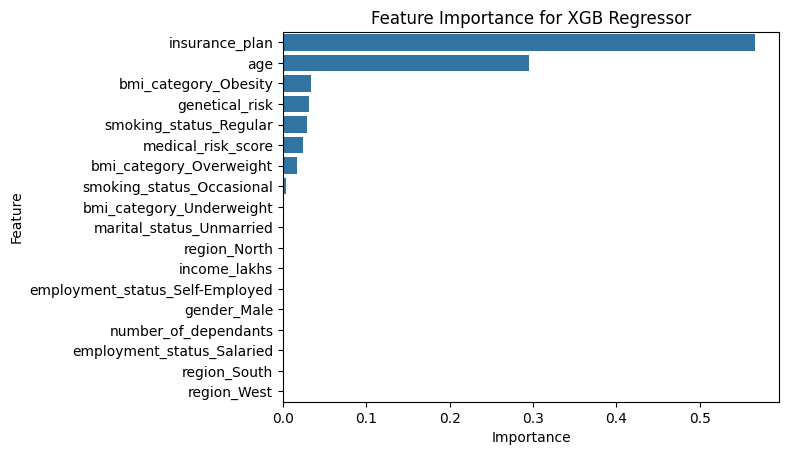

In [83]:
# feature importane for XGB Regresson
feature_importance = model_xgb.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for XGB Regressor')
plt.show()

In [86]:
y_pred = model_xgb.predict(X_test)

residuals = y_test - y_pred
residuals_pct = (residuals / y_test) * 100

residuals_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Residuals': residuals, 'Residuals_Pct': residuals_pct})
residuals_df.head()

,Actual,Predicted,Residuals,Residuals_Pct
30831,8698,8626.741211,71.258789,0.819255
31470,8786,9036.914062,-250.914062,-2.855840
20947,17456,17501.015625,-45.015625,-0.257881
33854,12308,12092.435547,215.564453,1.751417
7284,17484,17546.833984,-62.833984,-0.359380


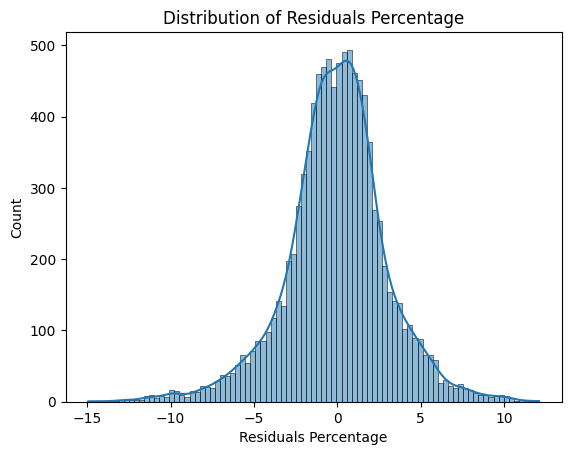

In [87]:
sns.histplot(residuals_df['Residuals_Pct'], kde=True)
plt.title('Distribution of Residuals Percentage')
plt.xlabel('Residuals Percentage')
plt.show()

In [88]:
extreme_residuals = residuals_df[residuals_df['Residuals_Pct'].abs() > 7]
print(residuals_df.shape[0])
print(extreme_residuals.shape[0])

9984
371


In [92]:
extreme_from_X = df3.loc[extreme_residuals.index]
extreme_from_X.head()

,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,annual_premium_amount,medical_risk_score,gender_Male,region_North,region_South,region_West,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
40317,21,1,18,1,0,4096,6,1,0,0,0,1,0,0,0,0,0,0,0
34430,19,0,1,1,1,5593,0,0,1,0,0,1,0,0,1,0,0,1,0
49577,22,0,25,1,1,4664,0,1,0,0,0,1,0,0,0,0,0,1,0
38690,18,0,27,1,0,3550,0,1,1,0,0,1,0,0,0,0,0,0,1
44401,22,3,34,1,1,5366,0,1,0,0,1,0,0,0,0,0,0,0,0


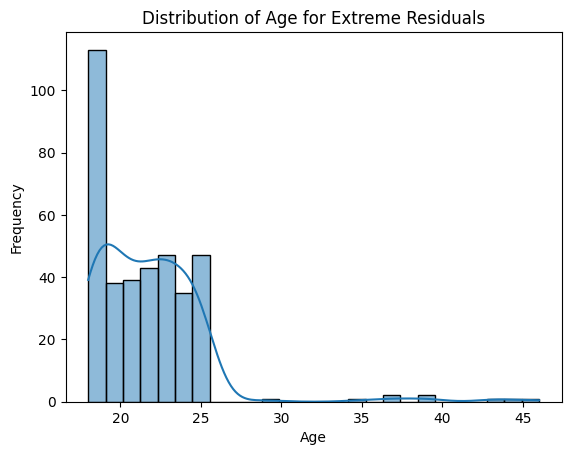

In [93]:


sns.histplot(extreme_from_X['age'], kde=True)
plt.title('Distribution of Age for Extreme Residuals')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

Since majority of errors we are seeing belong to the age group <25. Hence we will have to create two saparate models for each age group i.e > 25 and <25.